## Coursework. Building a model of future stock returns of public companies, taking into account their dividend policy and financial characteristics.

### Parsing info for Dataset:

The goal it to parse the dataset with at least 10 parametres and 20 000 strokes.

Firstly, it's reasonable to dowload a ".csv" file with the list of S&P companies, which information will be parsed.

Below there is a code, generated by Open AI ChatGPT 5.2 with a prompt:
"Generate me a parser for a dataset within at least 10 parametres and 20 000 strokes. The method should be free and relyable"

Beforehand it's needed to unite 3 tables, which are downloaded by the links:

    iShares Core S&P 500 ETF (507 tickers):
https://www.ishares.com/us/products/239726/ishares-core-sp-500-etf

    iShares Core S&P Mid-Cap ETF (409 tickers):
https://www.ishares.com/us/products/239763/ishares-core-sp-midcap-etf

    iShares Core S&P Small-Cap ETF (658 tickers):
https://www.ishares.com/us/products/239774/ishares-core-sp-smallcap-etf


Such method is used to reach desired amount of data

In [ ]:
!pip install -U yfinance

In [ ]:
import time
import math
import re
import numpy as np
import pandas as pd
import yfinance as yf

INPUT_CSV = "list of companies.csv"
MAX_TICKERS = 1500
YEARS = 10
SLEEP = 0.12
SAVE_EVERY = 200

OUT_CSV = "div_panel_final.csv"
OUT_PART_PREFIX = "div_panel_part_"

def normalize_ticker(x):
    if x is None:
        return None
    t = str(x).strip()
    if not t or t.lower() == "nan":
        return None
    t = t.replace("NYSE:", "").replace("NASDAQ:", "").replace("AMEX:", "").strip()
    t = t.split()[0].strip()

    t = t.replace(".", "-")
    if not re.fullmatch(r"[A-Za-z0-9\-\^=]+", t):
        return None
    return t.upper()


def read_tickers_any_shape(path):
    try:
        df = pd.read_csv(path)
        possible_cols = ["ticker", "Tickers", "symbol", "Symbol", "SYMBOL", "TICKER", "Ticker"]
        col = None
        for c in possible_cols:
            if c in df.columns:
                col = c
                break

        if col is not None:
            raw = df[col].tolist()
        else:
            raw = list(df.columns) + df.iloc[:, 0].astype(str).tolist()
    except:
        df = pd.read_csv(path, header=None)
        raw = df.iloc[:, 0].astype(str).tolist()
    tickers = []
    for x in raw:
        t = normalize_ticker(x)
        if t is not None:
            tickers.append(t)

    seen = set()
    uniq = []
    for t in tickers:
        if t not in seen:
            seen.add(t)
            uniq.append(t)
    return uniq


def nearest_close(px_df, d):
    tmp = px_df[px_df["Date"] <= d]
    if tmp.empty:
        return np.nan
    return float(tmp.iloc[-1]["Close"])

def compute_div_ttm(divs, end_date):
    start_date = end_date - pd.Timedelta(days=365)
    part = divs[(divs.index > start_date) & (divs.index <= end_date)]
    if part.empty:
        return 0.0
    return float(part.sum())


def build_one_ticker_div_panel(ticker, years=10):
    tkr = yf.Ticker(ticker)
    try:
        divs = tkr.dividends
    except:
        divs = None

    if divs is None or len(divs) == 0:
        divs = pd.Series(dtype=float)

    if not divs.empty:
        divs = divs.copy()
        divs.index = pd.to_datetime(divs.index).tz_localize(None)
        divs = divs.sort_index()

    end_date = pd.Timestamp.today().normalize()
    start_date = end_date - pd.Timedelta(days=365 * years + 370)

    px = tkr.history(start=start_date.date().isoformat(),
                     end=(end_date + pd.Timedelta(days=3)).date().isoformat(),
                     auto_adjust=False)

    if px is None or px.empty:
        return None

    px = px.reset_index()
    if "Date" not in px.columns:
        px.rename(columns={px.columns[0]: "Date"}, inplace=True)
    px["Date"] = pd.to_datetime(px["Date"]).dt.tz_localize(None)
    px = px.sort_values("Date")
    q_dates = pd.date_range(start=start_date, end=end_date, freq="Q")
    if len(q_dates) < 8:
        return None

    beta = np.nan
    try:
        info = tkr.info or {}
        beta = float(info.get("beta")) if info.get("beta") is not None else np.nan
    except:
        pass

    rows = []
    for d in q_dates:
        d = pd.Timestamp(d).normalize()
        price = nearest_close(px, d)

        div_ttm = np.nan
        if divs is not None:
            try:
                div_ttm = compute_div_ttm(divs, d)
            except:
                div_ttm = np.nan

        div_yield_ttm = np.nan
        if not math.isnan(price) and price > 0 and not math.isnan(div_ttm):
            div_yield_ttm = div_ttm / price

        rows.append({
            "ticker": ticker,
            "date": d,
            "close": price,
            "beta": beta,
            "div_ttm": div_ttm,
            "div_yield_ttm": div_yield_ttm,
            "has_dividends": 0 if (divs is None or divs.empty) else 1,
        })
    df = pd.DataFrame(rows).dropna(subset=["close"])
    if df.empty or len(df) < 8:
        return None

    df["close_qoq"] = df["close"].pct_change()
    df["close_yoy"] = df["close"].pct_change(4)

    df["div_ttm_qoq"] = df["div_ttm"].pct_change()
    df["div_ttm_yoy"] = df["div_ttm"].pct_change(4)

    px2 = px[["Date", "Close"]].copy()
    px2["ret"] = px2["Close"].pct_change()

    vol_list = []
    for d in df["date"]:
        start = d - pd.Timedelta(days=90)
        part = px2[(px2["Date"] > start) & (px2["Date"] <= d)]
        if part["ret"].dropna().empty:
            vol_list.append(np.nan)
        else:
            vol_list.append(float(part["ret"].std() * math.sqrt(252)))
    df["vol_annualized_90d"] = vol_list

    df["momentum_12m"] = df["close"].pct_change(4)
    df = df.tail(4 * years)

    return df

def main():
    tickers = read_tickers_any_shape(INPUT_CSV)
    tickers = tickers[:MAX_TICKERS]

    print("Tickers loaded:", len(tickers))
    print("First 20:", tickers[:20], flush=True)
    test = build_one_ticker_div_panel("AAPL", years=YEARS)
    if test is None:
        print("ERROR: even AAPL price/dividends not available via yfinance in this environment.")
        return

    out_parts = []
    ok = 0
    failed = []

    for i, t in enumerate(tickers, start=1):
        df = None
        try:
            df = build_one_ticker_div_panel(t, years=YEARS)
        except:
            df = None

        if df is not None and not df.empty:
            out_parts.append(df)
            ok += 1
        else:
            failed.append(t)

        time.sleep(SLEEP)

        if i % SAVE_EVERY == 0 and len(out_parts) > 0:
            part = pd.concat(out_parts, ignore_index=True)
            part.to_csv(f"{OUT_PART_PREFIX}{i}.csv", index=False)
            out_parts = []

        print(f"{i}/{len(tickers)} done, ok={ok}, failed={len(failed)}", flush=True)
    if len(out_parts) > 0:
        part = pd.concat(out_parts, ignore_index=True)
        part.to_csv(f"{OUT_PART_PREFIX}last.csv", index=False)

    parts = []
    for i in range(SAVE_EVERY, (len(tickers)//SAVE_EVERY)*SAVE_EVERY + 1, SAVE_EVERY):
        try:
            parts.append(pd.read_csv(f"{OUT_PART_PREFIX}{i}.csv"))
        except:
            pass
    try:
        parts.append(pd.read_csv(f"{OUT_PART_PREFIX}last.csv"))
    except:
        pass

    if len(parts) == 0:
        print("No data collected.")
        pd.Series(failed).to_csv("failed_tickers.csv", index=False)
        return

    panel = pd.concat(parts, ignore_index=True)
    panel = panel.dropna(subset=["ticker", "date", "close"])
    panel = panel.sort_values(["ticker", "date"])

    panel.to_csv(OUT_CSV, index=False)
    pd.Series(failed).to_csv("failed_tickers.csv", index=False)

    print("FINAL rows:", len(panel))
    print("FINAL cols:", len(panel.columns))
    print(panel.head(5).to_string(index=False))
    print("Saved:", OUT_CSV, "and failed_tickers.csv")


if __name__ == "__main__":
    main()

Tickers loaded: 1500
First 20: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRKB', 'LLY', 'JPM', 'XOM', 'JNJ', 'WMT', 'V', 'MU', 'COST', 'MA', 'ABBV']


C:\Users\РђРЅРґСЂРµР№\AppData\Local\Temp\ipykernel_13152\1725395773.py:139: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_dates = pd.date_range(start=start_date, end=end_date, freq="Q")
C:\Users\РђРЅРґСЂРµР№\AppData\Local\Temp\ipykernel_13152\1725395773.py:139: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_dates = pd.date_range(start=start_date, end=end_date, freq="Q")


1/1500 done, ok=1, failed=0


C:\Users\РђРЅРґСЂРµР№\AppData\Local\Temp\ipykernel_13152\1725395773.py:139: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_dates = pd.date_range(start=start_date, end=end_date, freq="Q")


2/1500 done, ok=2, failed=0


...

1498/1500 done, ok=1451, failed=47


C:\Users\РђРЅРґСЂРµР№\AppData\Local\Temp\ipykernel_13152\1725395773.py:139: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_dates = pd.date_range(start=start_date, end=end_date, freq="Q")


1499/1500 done, ok=1452, failed=47


C:\Users\РђРЅРґСЂРµР№\AppData\Local\Temp\ipykernel_13152\1725395773.py:139: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_dates = pd.date_range(start=start_date, end=end_date, freq="Q")


1500/1500 done, ok=1453, failed=47
FINAL rows: 55324
FINAL cols: 13
ticker       date     close  beta  div_ttm  div_yield_ttm  has_dividends  close_qoq  close_yoy  div_ttm_qoq  div_ttm_yoy  vol_annualized_90d  momentum_12m
     A 2016-03-31 39.849998 1.298    0.315       0.007905              1  -0.046879  -0.040915    -0.388350    -0.348181            0.288290     -0.040915
     A 2016-06-30 44.360001 1.298    0.445       0.010032              1   0.113174   0.149819     0.412698     0.128236            0.221781      0.149819
     A 2016-09-30 47.090000 1.298    0.460       0.009769              1   0.061542   0.371687     0.033708     0.150000            0.202809      0.371687
     A 2016-12-31 45.560001 1.298    0.477       0.010470              1  -0.032491   0.089691     0.036957    -0.073786            0.223929      0.089691
     A 2017-03-31 52.869999 1.298    0.609       0.011519              1   0.160448   0.326725     0.276730     0.933333            0.190180      0.326725
Sa

### Let's convey an exploratary data analysis:


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('div_panel_final.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55324 entries, 0 to 55323
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ticker              55324 non-null  str    
 1   date                55324 non-null  str    
 2   close               55324 non-null  float64
 3   beta                54135 non-null  float64
 4   div_ttm             42151 non-null  float64
 5   div_yield_ttm       42151 non-null  float64
 6   has_dividends       55324 non-null  int64  
 7   close_qoq           55124 non-null  float64
 8   close_yoy           54464 non-null  float64
 9   div_ttm_qoq         37154 non-null  float64
 10  div_ttm_yoy         37347 non-null  float64
 11  vol_annualized_90d  55316 non-null  float64
 12  momentum_12m        54464 non-null  float64
dtypes: float64(10), int64(1), str(2)
memory usage: 5.5 MB


The recieved dataset is 55324 strokes, 13 parametres - accepted

In [ ]:
df.head()


,ticker,date,close,beta,div_ttm,div_yield_ttm,has_dividends,close_qoq,close_yoy,div_ttm_qoq,div_ttm_yoy,vol_annualized_90d,momentum_12m
0,A,2016-03-31,39.849998,1.298,0.315,0.007905,1,-0.046879,-0.040915,-0.388350,-0.348181,0.288290,-0.040915
1,A,2016-06-30,44.360001,1.298,0.445,0.010032,1,0.113174,0.149819,0.412698,0.128236,0.221781,0.149819
2,A,2016-09-30,47.090000,1.298,0.460,0.009769,1,0.061542,0.371687,0.033708,0.150000,0.202809,0.371687
3,A,2016-12-31,45.560001,1.298,0.477,0.010470,1,-0.032491,0.089691,0.036957,-0.073786,0.223929,0.089691
4,A,2017-03-31,52.869999,1.298,0.609,0.011519,1,0.160448,0.326725,0.276730,0.933333,0.190180,0.326725


Disclaimer: all syntaxis of formulas in markdown was made by OpenAI ChatGPT 5.2

Firstly, let's find out what's the meaning of every feature for the convenience of further investigation:

**ticker** = the identification of the company (name)

**date** = date of the end of the quarter

**close** = price at the stock at the "date"

**beta** = the parameter represents systematic risk:
- beta is equal to 1 -> the shares move with the market
- beta is bigger than 1 -> shares are more volatile than the market
- beta is less than 1 -> usually "defensive" shares

**div_ttm** = the sum of dividents for last 12 months. It meausures in dollars per share. (may not be < 0)

**div_yield_ttm** = div_ttm / close - profitability of dividents

**has_dividents** = binary representation of having dividents or not

**close_qoq** = quartily profitablitity

$$\text{close\_qoq} = \frac{P_t - P_{t-1}}{P_{t-1}}$$

**close_yoy** = yearly income of the price

**div_ttm_qoq** = change of dividents by quarter

$$\text{div\_ttm\_qoq} = \frac{Div_t - Div_{t-1}}{Div_{t-1}}$$

**div_ttm_yoy** = yearly increase of dividents

**vol_annualized_90d** = annualized volatility over 90 days

$$\sigma = \text{std}(r_t) \times \sqrt{252}$$

In [ ]:
df = df.drop(columns=["momentum_12m"])

df.head()

,ticker,date,close,beta,div_ttm,div_yield_ttm,has_dividends,close_qoq,close_yoy,div_ttm_qoq,div_ttm_yoy,vol_annualized_90d
0,A,2016-03-31,39.849998,1.298,0.315,0.007905,1,-0.046879,-0.040915,-0.388350,-0.348181,0.288290
1,A,2016-06-30,44.360001,1.298,0.445,0.010032,1,0.113174,0.149819,0.412698,0.128236,0.221781
2,A,2016-09-30,47.090000,1.298,0.460,0.009769,1,0.061542,0.371687,0.033708,0.150000,0.202809
3,A,2016-12-31,45.560001,1.298,0.477,0.010470,1,-0.032491,0.089691,0.036957,-0.073786,0.223929
4,A,2017-03-31,52.869999,1.298,0.609,0.011519,1,0.160448,0.326725,0.276730,0.933333,0.190180


## Data quality

Let's whats the shares of missing values of each parameter (in percentage):

In [ ]:
missing_values_percentage = (df.isna().mean() * 100).round(2)
print(missing_values_percentage)

ticker                 0.00
date                   0.00
close                  0.00
beta                   2.15
div_ttm               23.81
div_yield_ttm         23.81
has_dividends          0.00
close_qoq              0.36
close_yoy              1.55
div_ttm_qoq           32.84
div_ttm_yoy           32.49
vol_annualized_90d     0.01
dtype: float64


Additionally, checking for duplicates:

Firstly, duplicates of strokes.

In [ ]:
print(df.duplicated().sum())

0


Here we can conclude that many companies dont pay dividents (ever on the given data):

In [ ]:
sum_per_ticker = df.groupby("ticker")["div_ttm"].sum()

percentage = ((sum_per_ticker == 0).sum() / sum_per_ticker.count()) * 100

print(percentage.round(2))

27.53


We can see that it's a huge percent! 5 parametres of 12 depend on it.

The next representative point is checking how valid every parameter is:

Additionally, let's make a plot that shows amount of entries per ticker (company). This will show us how comparable chosen companies are:

In [ ]:
def printing_function(parameter, interval):
    wrong_part = df.loc[interval, [parameter]]
    print(f"{len(wrong_part)} incorrect values of {parameter}")


print(f"{len(df)} - length of the dataset")

print("-" * 30)

wrong_ticker = df["ticker"].notna()
printing_function("ticker", ~wrong_ticker)

wrong_date = pd.to_datetime(df["date"], errors="coerce").isna()
printing_function("date", wrong_date)

wrong_close = (df["close"].isna()) |(df["close"] <= 0)
printing_function("close", wrong_close)

wrong_beta = (df["beta"].isna()) |(df["beta"] < -5 | (df["beta"] > 5))
printing_function("beta", wrong_beta)

wrong_div_ttm = (df["div_ttm"].isna()) |(df["div_ttm"] < 0)
printing_function("div_ttm", wrong_div_ttm)

wrong_div_yield_ttm = (df["div_yield_ttm"].isna()) |(df["div_yield_ttm"] < 0) | df["div_yield_ttm"] > 1
printing_function("div_yield_ttm", wrong_div_yield_ttm)

wrong_has_dividends = ~df["has_dividends"].isin([0, 1])
printing_function("has_dividends", wrong_has_dividends)

wrong_close_qoq = df["close_qoq"].isna()
printing_function("close_qoq", wrong_close_qoq)

wrong_close_yoy = df["close_yoy"].isna()
printing_function("close_yoy", wrong_close_yoy)

wrong_div_ttm_qoq = df["div_ttm_qoq"].isna()
printing_function("div_ttm_qoq", wrong_div_ttm_qoq)

wrong_div_ttm_yoy = df["div_ttm_yoy"].isna()
printing_function("div_ttm_yoy", wrong_div_ttm_yoy)

wrong_vol_annualized_90d = (df["vol_annualized_90d"].isna()) | (df["vol_annualized_90d"] <0)
printing_function("vol_annualized_90d", wrong_vol_annualized_90d)



55324 - length of the dataset
------------------------------
0 incorrect values of ticker
0 incorrect values of date
0 incorrect values of close
27546 incorrect values of beta
13173 incorrect values of div_ttm
0 incorrect values of div_yield_ttm
0 incorrect values of has_dividends
200 incorrect values of close_qoq
860 incorrect values of close_yoy
18170 incorrect values of div_ttm_qoq
17977 incorrect values of div_ttm_yoy
8 incorrect values of vol_annualized_90d


We've found that some parametres have incorrect values. Let's consider them:

Some parametres have a lot of incorrect values, especially beta (almost half of the dataset) and the dividend-related ones. But most of these are just NaN-s for companies that don't pay dividents, so dropping these rows would mean losing a huge part of the dataset. We keep them, and handle the missing values later. Now let's check how many entries every company has:

Text(0, 0.5, 'Amount of companies')

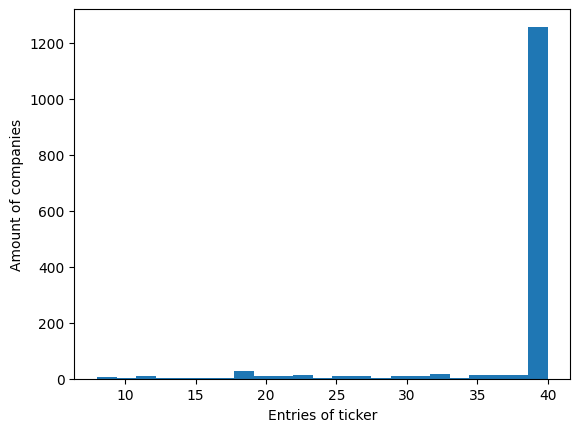

In [ ]:
amount_of_entries_per_company = df.groupby("ticker").size()
plt.hist(amount_of_entries_per_company, bins = 23)
plt.xlabel("Entries of ticker")
plt.ylabel("Amount of companies")

Now, let's calculate amount of companies that have less than 40 entries:

In [ ]:
less_than_40 = (amount_of_entries_per_company < 40).sum()
print((less_than_40 / amount_of_entries_per_company.count() * 100).round(2))

13.7


Let's calculate this share to take a desigion whether it's good idea, to omit these companies for purifing dataset

In [ ]:
print((less_than_40/ amount_of_entries_per_company.count() * 100).round(2))

13.7


Let's find the correlation of every numeric parameter:

<Axes: >

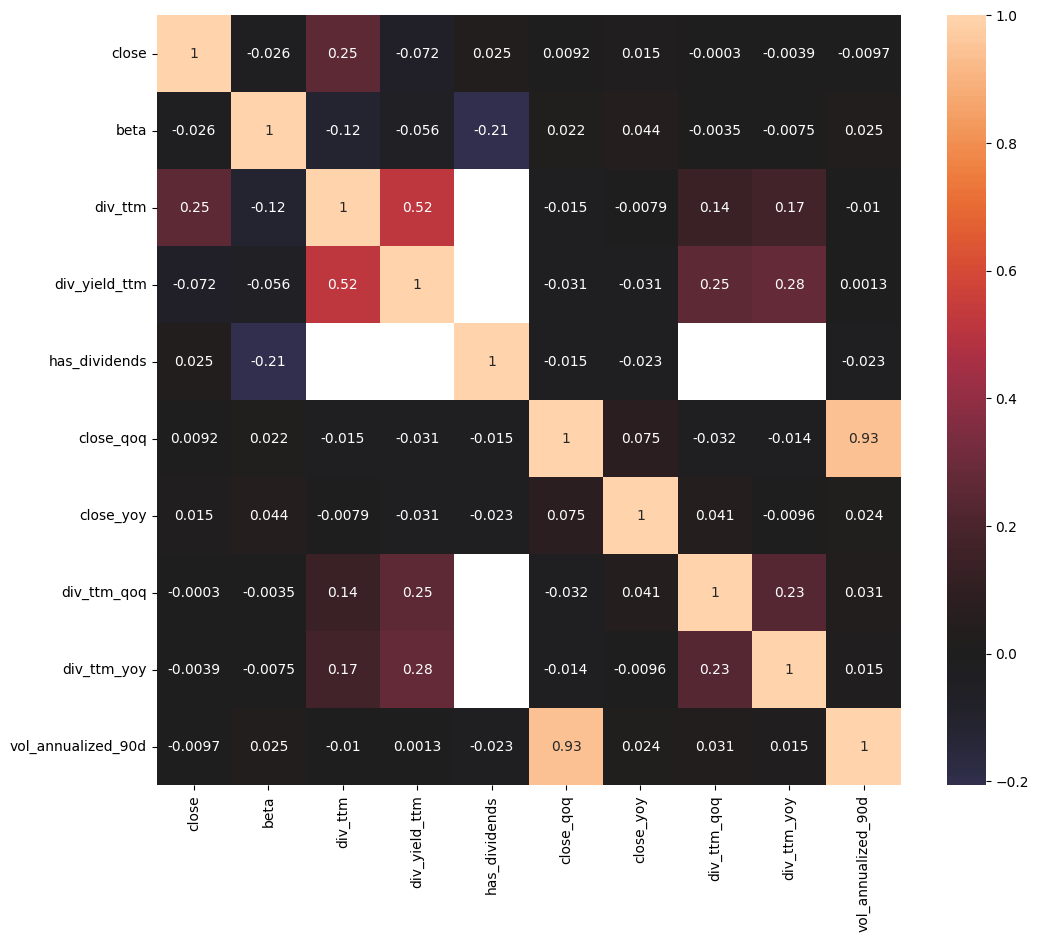

In [ ]:
numeric_parametres = df.select_dtypes(include = [np.number])
corr = numeric_parametres.corr()
plt.figure(figsize = (12, 10))
sns.heatmap(
    corr,
    annot = True,
    center = 0
)



> **Observation of the graph:** The highest correlation on the chart between close_qoq and vol_annualized_90d is 0.93 (highlighted in ochre on the chart). The second-highest correlation is between div_ttm and div_yield_ttm, which makes sense overall, since the larger the dividend, the higher the yield. The remaining groups have less significant correlations.

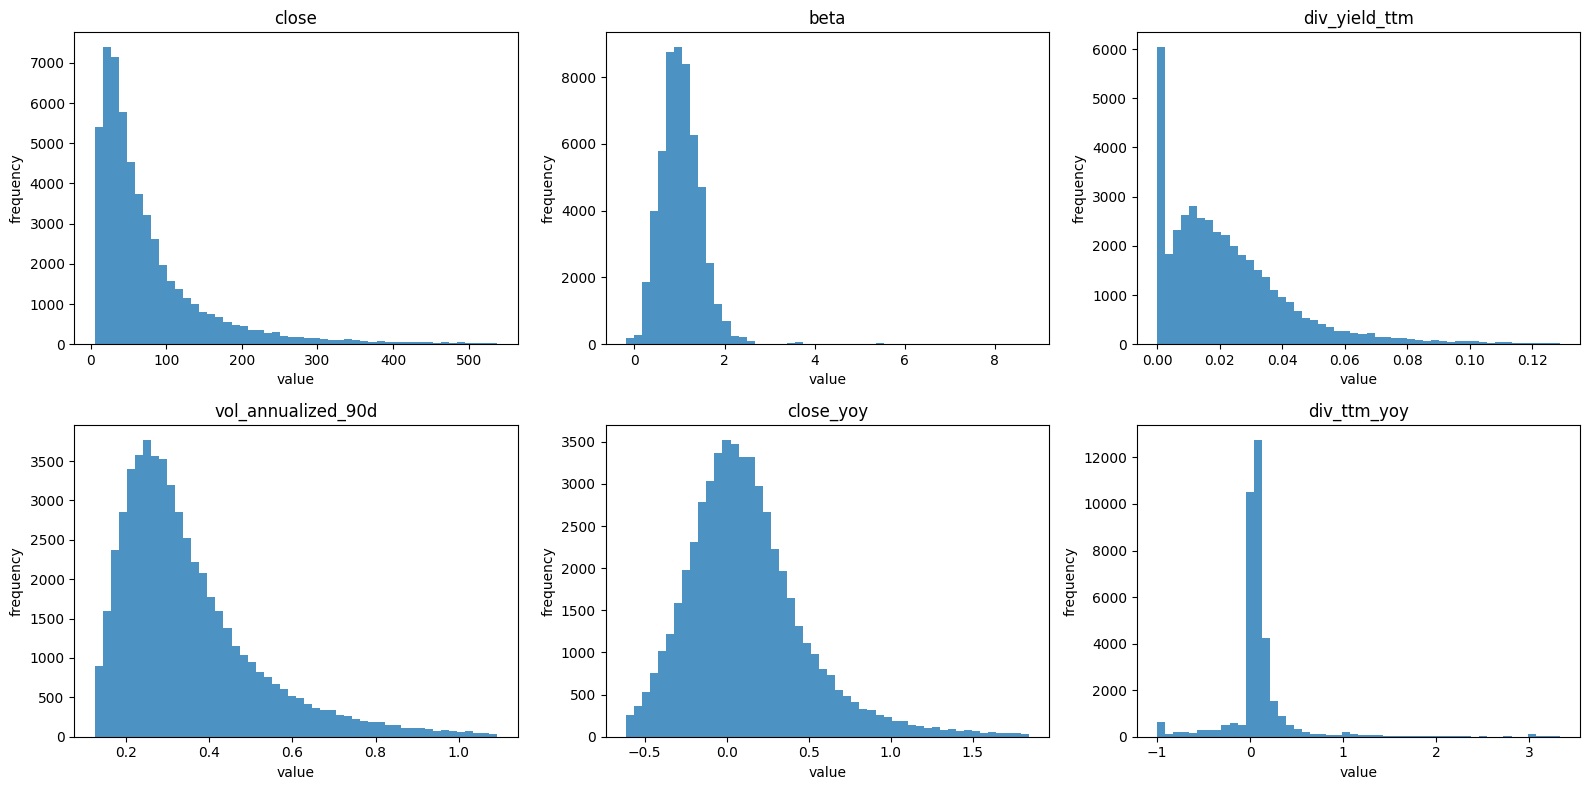

In [ ]:
chosen_part = ["close", "beta", "div_yield_ttm", "vol_annualized_90d", "close_yoy", "div_ttm_yoy"]
figure, ax = plt.subplots(2, 3, figsize=(16, 8))
ax = ax.flatten()

for i, column in enumerate(chosen_part):
    dataset2 = df[column].replace([np.inf, -np.inf], np.nan).dropna()

    if column != "beta":
        low = dataset2.quantile(0.01)
        high = dataset2.quantile(0.99)
        dataset2 = dataset2[(dataset2 >= low) & (dataset2 <= high)]

    ax[i].hist(dataset2, bins=50, edgecolor="none", alpha=0.8)
    ax[i].set_title(column)
    ax[i].set_xlabel("value")
    ax[i].set_ylabel("frequency")

plt.tight_layout()
plt.show()

### Observation of the graph:

| Parameter | Interpretation |
|---|---|
| **close** | Most companies in the dataset have stock prices ranging from 50<span>$</span> to 100&#36; |
| **beta** | This is a fairly predictable pattern for top-tier global companies. On average, their growth rate is 1 to 1.5 times that of the market, which indicates that they are growing slightly faster than the market as a whole |
| **div\_yield\_ttm** | It is clear that the vast majority of companies do not pay dividends, or pay only minimal amounts. A yield above 5 percent, as shown in the chart, is rare |
| **vol\_annualized\_90d** | On average, volatility ranges from 20 to 30 percent; anything beyond that is the result of crises and market turmoil |
| **close\_yoy** | Here, the approximation is closest to the normal, judging by the graph |
| **div\_ttm\_yoy** | There is a sharp spike around 0, which means that many companies either do not pay dividends at all or have not changed the amount of their payouts. On the right side of the chart, you can see that only a few are increasing their dividend payouts |

> **Conclusion:** Based on the graphs, it can be seen that tests assuming a normal distribution of data cannot be performed. This is further taken into account in hypothesis 1, and the transition to Mann-Whitney is performed.

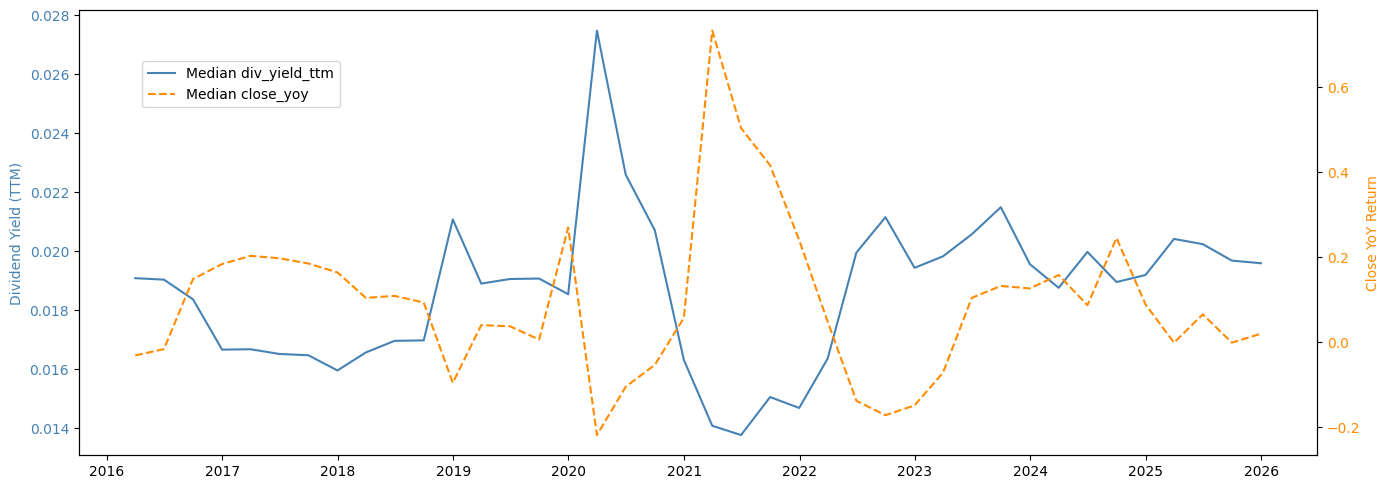

In [ ]:
df["date"] = pd.to_datetime(df["date"])
div_time = (
    df[df["has_dividends"] == 1].groupby("date")["div_yield_ttm"].median()
)
close_time = (
    df.groupby("date")["close_yoy"].median()
)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(div_time.index, div_time.values, color="steelblue", label="Median div_yield_ttm")
ax1.set_ylabel("Dividend Yield (TTM)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(close_time.index, close_time.values, color="darkorange", linestyle="--", label="Median close_yoy")
ax2.set_ylabel("Close YoY Return", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

> **Observation of the graph:** An interesting fact is that medians do not move in the same direction; on the contrary, they tend to move in different directions during times of crisis. This is further confirmed by Hypothesis 2, which states that volatility does not directly explain dividend yield. Otherwise, apart from the 2020вЂ“2022 crisis, the medians are relatively close to each other, and the average stock yield ranges from 1.6 to 2.2 percent.

C:\Users\РљРёСЂРёР»Р»\AppData\Local\Temp\ipykernel_27524\359385607.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


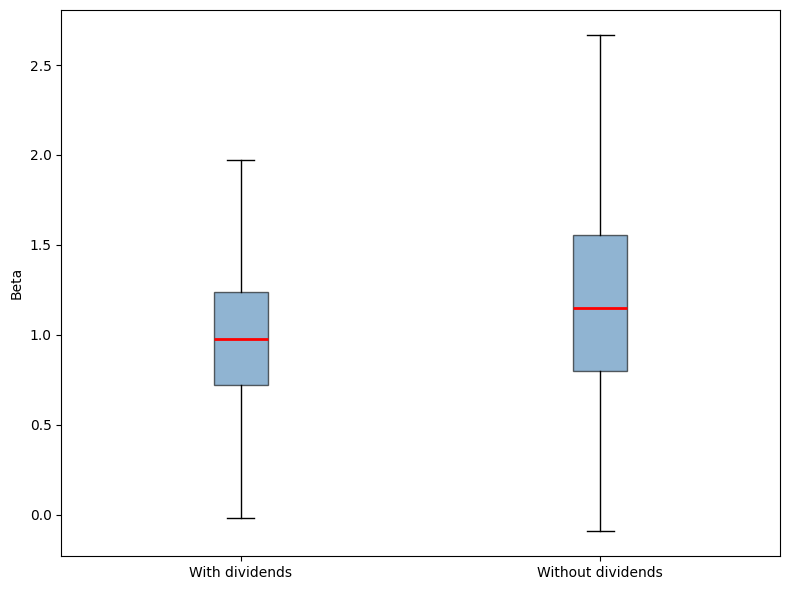

In [ ]:
groups = {
    "With dividends": df.loc[df["has_dividends"] == 1, "beta"].dropna(),
    "Without dividends": df.loc[df["has_dividends"] == 0, "beta"].dropna(),
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    groups.values(),
    labels=groups.keys(),
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="red", linewidth=2),
    showfliers=False
)
ax.set_ylabel("Beta")
plt.tight_layout()
plt.show()

> **Observation of the graph:** Here we see that companies that pay dividends are, on average, more clustered around the medianвЂ”which can be seen as a sign of greater stability. Their risk level (beta) is also, on average, significantly lower. In the first case (with dividends), it is approximately 1, while in the second case (without dividends), it is roughly 1.2.

### Hypothesis 1
$H_0$: $\overline{\beta_1} = \overline{\beta_0}$

$H_1$: $\overline{\beta_1} \neq \overline{\beta_0}$

The average beta for dividend-paying companies is (not) equal to the average beta for non-dividend-paying companies.

For checking whether the hypothesis is valid or not, here the most suitable will be 2-sample t-test:

In [ ]:
from scipy import stats

with_dividents = df.loc[df["has_dividends"] == 1, "beta"].dropna()
without_dividents = df. loc[df["has_dividends"] == 0, "beta"].dropna()
print(len(with_dividents), "entries with dividents")
print(len(without_dividents), "entries without dividents")


41447 entries with dividents
12688 entries without dividents


Now we are to check the normality within Shapiro-Wilk, but in the documetation**. It's pointed out that subsets may be not so representative if their sise > 5000

**link to sharipo data: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html

"The algorithm used is described in [4] but censoring parameters as described are not implemented. For N > 5000 the W test statistic is accurate, but the p-value may not be."

In [ ]:


First_group = with_dividents.sample(min(len(with_dividents), 5000), random_state = 42)
Second_group = without_dividents.sample(min(len(without_dividents), 5000), random_state = 42)

First_shapiro = stats.shapiro(First_group)
Second_shapiro = stats.shapiro(Second_group)

print(f"Have dividenst: {First_shapiro.statistic:.4f}, p-value = {First_shapiro.pvalue:.10f}")
print(f"Don't Have dividenst: {Second_shapiro.statistic:.4f}, p-value = {Second_shapiro.pvalue:.10f}")

Have dividenst: 0.9941, p-value = 0.0000000000
Don't Have dividenst: 0.8387, p-value = 0.0000000000


Both p-values are very close to zero, so we reject the null hypothesis of normality for both groups. Especially for the second group "Don't have dividents", the statistic is far from 1.

Here we can see that statistics for group of "Don't have dividents" is not close to normal, so we're using Mann-Whitney U test***

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html

In [ ]:
New_test = stats.mannwhitneyu(with_dividents, without_dividents, alternative = "two-sided")

print(f"Mean for have dividends = {with_dividents.mean():.4f}")
print(f"Mean for don't have dividends = {without_dividents.mean():.4f}")
print(f"Statistics of U = {New_test.statistic:.4f}")
print(f"p-value of the test = {New_test.pvalue:.10f}")




Mean for have dividends = 0.9808
Mean for don't have dividends = 1.2072
Statistics of U = 200364033.0000
p-value of the test = 0.0000000000


In [ ]:
print(f"The difference of the risk is {(100 - (with_dividents.mean()) / without_dividents.mean() * 100):.2f}%")

The difference of the risk is 18.75%


Now it's valid test! The difference is pretty recognizable. We have proved the hypothesis. Generally speaking, in companies who pay dividents the risk is lower by 18.75%

### Hypothesis 2
$H_0$: $\beta = 0$

$H_1$: $\beta < 0$

The model is:

$$\text{div\_yield\_ttm} = \alpha + \beta \cdot \text{vol\_annualized\_90d} + \varepsilon$$

Volatility moves in the exact opposite direction to dividend yield.

For checking that we use OLS Regression (It implies that SE-s are independent and have the same dispersion)

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

chosen_values = df[["div_yield_ttm", "vol_annualized_90d"]].dropna().copy()

# Check scales before fitting
print("Scales of features before standardization:")
print(chosen_values.describe())
print()

# Standardize both features so regression coefficients are comparable
scaler = StandardScaler()
chosen_scaled = pd.DataFrame(
    scaler.fit_transform(chosen_values),
    columns=chosen_values.columns
)

x_axis = chosen_scaled["vol_annualized_90d"]
y_axis = chosen_scaled["div_yield_ttm"]

x_axis = sm.add_constant(x_axis)
model = sm.OLS(y_axis, x_axis).fit()
print(len(chosen_values))
print(model.summary())

42147
                            OLS Regression Results                            
Dep. Variable:          div_yield_ttm   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.07052
Date:                Tue, 21 Apr 2026   Prob (F-statistic):              0.791
Time:                        20:52:20   Log-Likelihood:                 67581.
No. Observations:               42147   AIC:                        -1.352e+05
Df Residuals:                   42145   BIC:                        -1.351e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0248 

Durbin-Watson (= 0.451) isn't representative here. Thus, we're to choose another model

The more suitable one may be the method of clustered standart errors. It implies that observations from various companies are independent. However inside one company SE-s may be dependent and have the same dispersion level.

If a model is wrong about one quartile of the company, it will (more likely) have the same error in the other quartiles - because of it, SE-s are correlated and this should be included in model if possible.

This model may be more representative, because it includes this, whether OLS not.

In [ ]:
chosen_part = df[["div_yield_ttm", "vol_annualized_90d", "ticker"]].dropna().copy()

# Standardize before cluster-robust regression
scaler50 = StandardScaler()
chosen_part[["div_yield_ttm", "vol_annualized_90d"]] = scaler50.fit_transform(
    chosen_part[["div_yield_ttm", "vol_annualized_90d"]]
)

y_axis = chosen_part["div_yield_ttm"]
x_axis = sm.add_constant(chosen_part["vol_annualized_90d"])

CSE = sm.OLS(y_axis, x_axis).fit()
print(CSE.summary())

                            OLS Regression Results                            
Dep. Variable:          div_yield_ttm   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.07052
Date:                Tue, 21 Apr 2026   Prob (F-statistic):              0.791
Time:                        20:52:20   Log-Likelihood:                 67581.
No. Observations:               42147   AIC:                        -1.352e+05
Df Residuals:                   42145   BIC:                        -1.351e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0248      0

In [ ]:
clustered_updated = CSE.get_robustcov_results(
    cov_type = "cluster",
    groups = chosen_part["ticker"]
)
print(clustered_updated.summary())

                            OLS Regression Results                            
Dep. Variable:          div_yield_ttm   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.1051
Date:                Tue, 21 Apr 2026   Prob (F-statistic):              0.746
Time:                        20:52:20   Log-Likelihood:                 67581.
No. Observations:               42147   AIC:                        -1.352e+05
Df Residuals:                   42145   BIC:                        -1.351e+05
Df Model:                           1                                         
Covariance Type:              cluster                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0248      0

According to both tests, $H_0$ can't be rejected. Our coefficient is 2.487e-05, which is extremely small, when the probability is 0.746.

Generally speaking, we can't predict somehow the divident yield, basing only on volatility parameter. May be it's based on more complex model.

### Hypothesis 3
$H_0$: Dividend growth does not affect future stock returns.

$H_1$: Dividend growth affects future stock returns.

If dividends grow, then the stock's return is predicted. This can then be incorporated into my model as a factor for forecasting multiples.

Here, I guess, the most suitable test is **Granger Casuality**, it's exactly describes relation between macro indicators (divident growth) -> market relations (future stock returns).

But, firstly we should I find out whether high level of SE-s flactuation occurs. If not, then Granger will be suitable and representative. For checking that we may convey to pre-tests:

1) Augmented Dickey-Fuller (ADF) test which shows us signs of stationarity (small flactuation)
2) Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test which shows us signs of unstationarity (high flactuation)

Combining the results of both pre-test, we may make a conclusion.

Both tests were found on: https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests

chosen_part = (df.groupby("date")[["div_ttm_yoy", "close_yoy"]].median().dropna().sort_index())

statistics_adf, probability_adf, lags_adf, *_ = adfuller(chosen_part["div_ttm_yoy"], regression = "c", autolag = "AIC")
statistics_kpss, probability_kpss, lags_kpss, _ = kpss(chosen_part["div_ttm_yoy"], nlags = "auto")

statistics_adf2, probability_adf2, lags_adf2, *_ = adfuller(chosen_part["close_yoy"], regression = "c", autolag = "AIC")
statistics_kpss2, probability_kpss2, lags_kpss2, _ = kpss(chosen_part["close_yoy"], nlags = "auto")

print("div_ttm_yoy")
print(f"ADF : statistics = {statistics_adf:.4f}, p-value = {probability_adf:.4f}, lags that were used = {lags_adf}")
print(f"KPSS : statistics = {statistics_kpss:.4f}, p-value = {probability_kpss:.4f}, lags that were used = {lags_kpss}")
print("")
print("close_yoy")
print(f"ADF : statistics = {statistics_adf2:.4f}, p-value = {probability_adf2:.4f}, lags that were used = {lags_adf2}")
print(f"KPSS : statistics = {statistics_kpss2:.4f}, p-value = {probability_kpss2:.4f}, lags that were used = {lags_kpss2}")

div_ttm_yoy
ADF : statistics = -3.8382, p-value = 0.0025, lags that were used = 3
KPSS : statistics = 0.2286, p-value = 0.1000, lags that were used = 4

close_yoy
ADF : statistics = -3.1130, p-value = 0.0256, lags that were used = 5
KPSS : statistics = 0.0484, p-value = 0.1000, lags that were used = 3


C:\Users\РљРёСЂРёР»Р»\AppData\Local\Temp\ipykernel_27524\2921480530.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistics_kpss, probability_kpss, lags_kpss, _ = kpss(chosen_part["div_ttm_yoy"], nlags = "auto")
C:\Users\РљРёСЂРёР»Р»\AppData\Local\Temp\ipykernel_27524\2921480530.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistics_kpss2, probability_kpss2, lags_kpss2, _ = kpss(chosen_part["close_yoy"], nlags = "auto")


Copying the output we make such a conclustion:

    div_ttm_yoy:

ADF : p-value = 0.0025 **-> we reject nonstationarity**

KPSS :p-value = 0.1000 **-> we don't reject stationarity**

    close_yoy:

ADF : p-value = 0.0256 **-> we reject nonstationarity**

KPSS :p-value = 0.1000 **-> we don't reject stationarity**

**Thus, we may convey the Granger Casuality test**
https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.grangercausalitytests.html


In [ ]:
grangercausalitytests(chosen_part[["div_ttm_yoy", "close_yoy"]], maxlag = 4)

print("")
print("")
print("")
grangercausalitytests(chosen_part[["close_yoy", "div_ttm_yoy"]], maxlag = 4)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=9.4003  , p=0.0041  , df_denom=36, df_num=1
ssr based chi2 test:   chi2=10.1837 , p=0.0014  , df=1
likelihood ratio test: chi2=9.0480  , p=0.0026  , df=1
parameter F test:         F=9.4003  , p=0.0041  , df_denom=36, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.9382  , p=0.1600  , df_denom=33, df_num=2
ssr based chi2 test:   chi2=4.4638  , p=0.1073  , df=2
likelihood ratio test: chi2=4.2205  , p=0.1212  , df=2
parameter F test:         F=1.9382  , p=0.1600  , df_denom=33, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.3055  , p=0.0335  , df_denom=30, df_num=3
ssr based chi2 test:   chi2=12.2303 , p=0.0066  , df=3
likelihood ratio test: chi2=10.5669 , p=0.0143  , df=3
parameter F test:         F=3.3055  , p=0.0335  , df_denom=30, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.0443  , p=0.0341  , df_d

{np.int64(1): ({'ssr_ftest': (np.float64(6.655135624074202),
    np.float64(0.014115702477127831),
    np.float64(36.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(7.209730259413718),
    np.float64(0.007250939096807171),
    np.int64(1)),
   'lrtest': (np.float64(6.615520916867581),
    np.float64(0.01010937645739977),
    np.int64(1)),
   'params_ftest': (np.float64(6.655135624074214),
    np.float64(0.014115702477127727),
    np.float64(36.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.537961542988782),
    np.float64(0.04054167518803224),
    np.float64(33.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(8.148032644459013),
    np.float64(0.017008937764534528),
    np.int64(2)),
   'lrtest': (np.float64(7.38219048753561),
    np.float64(0.024944666584896944),
    np.int64(2)),
   'params_ftest': (np.float64(3.5379615429887763),
    np.float64(0.04054167518803242),
    np.float64(33.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
     

Accroding to output we may reperesent the data more briefly:<br>


    close_yoy -> div_ttm_yoy <br>
lag 1: p=0.0041 (yes) <br>
lag 2: p=0.1600 (no) <br>
lag 3: p=0.0335 (yes) <br>
lag 4: p=0.0341 (yes) <br>

    div_ttm_yoy -> close_yoy <br>
lag 1: p=0.0141 (yes) <br>
lag 2: p=0.0405 (yes) <br>
lag 3: p=0.1257 (no) <br>
lag 4: p=0.0190 (yes) <br>

(if p-value < 0.05 -  valuable(yes), othervise unvaluable (no)) <br>
Here we can see that we can predict relation ship of close_yoy by div_ttm_yoy and vise versa. By the Grenger casuality we revealed that  in 3/4 lags in both tests the prediction will be valuable, thus previous entries may be representative for teaching the model.

Now we may move to the main gap of the servey:

# Building a model of future stock returns of public companies, taking into account their dividend policy and financial characteristics.

**The main purpose** of building the model is to answer a concrete question - how divident policy, risk and other finantial characteristics impact on the future stock returns.

We'll approach this in two phases. First, a straightforward regression on the annual return (`close_yoy` for each quarter t) with a small feature set, as a baseline. Then, in the second phase, a more elaborate setup: shorter horizon (next-quarter return), engineered features and a broader range of models including stacking. The plan is to see if the limiting factor is the model, the features, or the data itself.

## Preparation of the data

In [ ]:
df_raw = pd.read_csv('div_panel_final.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.drop(columns=["momentum_12m"], errors='ignore')
print(f"РЎС‚СЂРѕРє: {len(df_raw)}, РљРѕРјРїР°РЅРёР№: {df_raw['ticker'].nunique()}")

РЎС‚СЂРѕРє: 55324, РљРѕРјРїР°РЅРёР№: 1453


In [ ]:
df = df_raw.copy()

quarters_per_ticker = df.groupby('ticker')['date'].count()
valid_tickers = quarters_per_ticker[quarters_per_ticker >= 8].index
df = df[df['ticker'].isin(valid_tickers)]

df['target'] = df.groupby('ticker')['close_yoy'].shift(-4)
df = df.dropna(subset=['target'])

features = ['beta', 'div_ttm', 'div_yield_ttm', 'has_dividends',
            'close_qoq', 'div_ttm_yoy', 'vol_annualized_90d']
df[features] = df[features].replace([np.inf, -np.inf], np.nan)
df[features] = df[features].fillna(df[features].median())

print(f"Companies before filtering : {df_raw['ticker'].nunique()}")
print(f"Companies after (>= 8Q)    : {df['ticker'].nunique()}")
print(f"Strokes after target       : {len(df)}")

Companies before filtering : 1453
Companies after (>= 8Q)    : 1453
Strokes after target       : 49512


Now we're to check wether each company has enough data:

In [ ]:
quarters_per_ticker = df.groupby('ticker')['date'].count()
print("mean quartiles per company:", quarters_per_ticker.mean().round(1))
print("min:", quarters_per_ticker.min())
print("max:", quarters_per_ticker.max())

mean quartiles per company: 34.1
min: 4
max: 36


The last step is splitting the dataset into two parts: training and testing. We may split by date:
we move to aproximately 70% train, 30% test

In [ ]:
for split_date in pd.date_range('2020-01-01', '2024-06-01', freq='QS'):
    train_size = (df['date'] < split_date).sum()
    test_size  = (df['date'] >= split_date).sum()
    total = len(df)
    print(f"Split {split_date.date()}: Train {train_size} ({100*train_size/total:.1f}%)   Test {test_size} ({100*test_size/total:.1f}%)")

Split 2020-01-01: Train 21010 (42.4%)   Test 28502 (57.6%)
Split 2020-04-01: Train 22380 (45.2%)   Test 27132 (54.8%)
Split 2020-07-01: Train 23755 (48.0%)   Test 25757 (52.0%)
Split 2020-10-01: Train 25137 (50.8%)   Test 24375 (49.2%)
Split 2021-01-01: Train 26529 (53.6%)   Test 22983 (46.4%)
Split 2021-04-01: Train 27929 (56.4%)   Test 21583 (43.6%)
Split 2021-07-01: Train 29342 (59.3%)   Test 20170 (40.7%)
Split 2021-10-01: Train 30768 (62.1%)   Test 18744 (37.9%)
Split 2022-01-01: Train 32196 (65.0%)   Test 17316 (35.0%)
Split 2022-04-01: Train 33627 (67.9%)   Test 15885 (32.1%)
Split 2022-07-01: Train 35058 (70.8%)   Test 14454 (29.2%)
Split 2022-10-01: Train 36490 (73.7%)   Test 13022 (26.3%)
Split 2023-01-01: Train 37925 (76.6%)   Test 11587 (23.4%)
Split 2023-04-01: Train 39362 (79.5%)   Test 10150 (20.5%)
Split 2023-07-01: Train 40805 (82.4%)   Test 8707 (17.6%)
Split 2023-10-01: Train 42251 (85.3%)   Test 7261 (14.7%)
Split 2024-01-01: Train 43700 (88.3%)   Test 5812 (11.7%)


Here the closest date is: Split 2022-07-01: Train 35058 (70.8%)   Test 14454 (29.2%)

In [ ]:
SPLIT_DATE = '2022-07-01'
train = df[df['date'] < SPLIT_DATE].copy()
test  = df[df['date'] >= SPLIT_DATE].copy()

X_train = train[features]
y_train = train['target']
X_test  = test[features]
y_test  = test['target']

print(f"Train: {len(train)} rows ({100*len(train)/len(df):.1f}%)")
print(f"Test : {len(test)} rows ({100*len(test)/len(df):.1f}%)")

Train: 35058 rows (70.8%)
Test : 14454 rows (29.2%)


## Easiest model for comparison (OLS regression)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train_ols = sm.add_constant(X_train)
X_test_ols  = sm.add_constant(X_test)

ols = sm.OLS(y_train, X_train_ols).fit()

y_pred_ols = ols.predict(X_test_ols)

mae_ols  = mean_absolute_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
r2_ols   = r2_score(y_test, y_pred_ols)

print(f"MAE  : {mae_ols:.4f}")
print(f"RMSE : {rmse_ols:.4f}")
print(f"RВІ   : {r2_ols:.4f}")
print(ols.summary())

MAE  : 0.3127
RMSE : 0.4787
RВІ   : -0.0519
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     36.13
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.04e-50
Time:                        20:52:20   Log-Likelihood:                -80189.
No. Observations:               35058   AIC:                         1.604e+05
Df Residuals:                   35050   BIC:                         1.605e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

R² = -0.0519 -> That model totally doesn't fits our dataset, we should choose another one.

## First model: Random Forest type

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Training completed in 0.8 minutes
Best params : {'n_estimators': 200, 'min_samples_split': 15, 'min_samples_leaf': 20, 'max_features': 'log2', 'max_depth': None}
CV RВІ score : -0.0032
MAE         : 0.2970
RMSE        : 0.4703
RВІ          : -0.0154
           feature  importance
vol_annualized_90d    0.394875
         close_qoq    0.330906
              beta    0.154895
           div_ttm    0.062520
     div_yield_ttm    0.036253
       div_ttm_yoy    0.013899
     has_dividends    0.006654


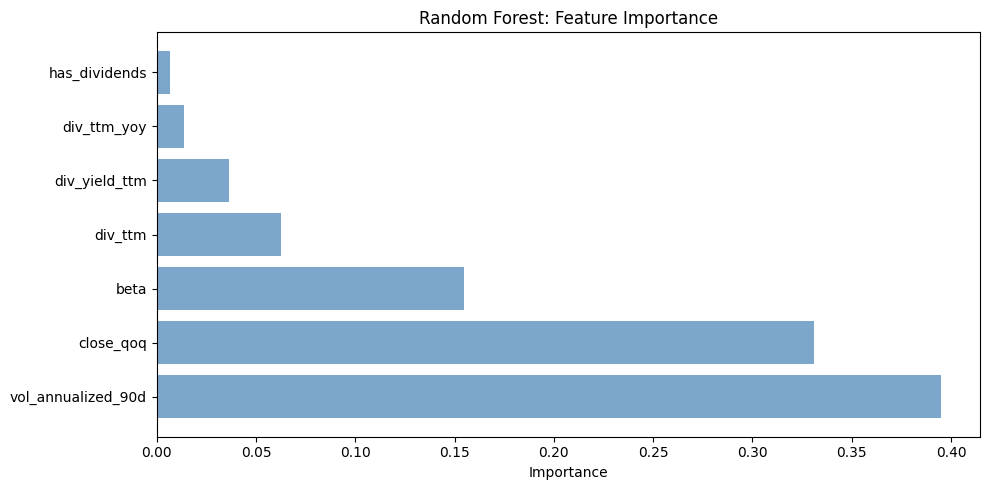

Model           MAE     RMSE       RВІ
OLS          0.3127   0.4787  -0.0519
RF           0.2970   0.4703  -0.0154


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [2, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 15],
    'max_features': ['sqrt', 'log2', 0.5]
}

tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=3,
    random_state=42,
    return_train_score=False
)

start_time = time.time()
rf_search.fit(X_train, y_train)
elapsed_total = (time.time() - start_time) / 60
print(f"Training completed in {elapsed_total:.1f} minutes")

rf = rf_search.best_estimator_
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Best params : {rf_search.best_params_}")
print(f"CV RВІ score : {rf_search.best_score_:.4f}")
print(f"MAE         : {mae_rf:.4f}")
print(f"RMSE        : {rmse_rf:.4f}")
print(f"RВІ          : {r2_rf:.4f}")

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'],
         color='steelblue', alpha=0.7)
plt.xlabel('Importance')
plt.title('Random Forest: Feature Importance')
plt.tight_layout()
plt.show()

print(f"{'Model':<10} {'MAE':>8} {'RMSE':>8} {'RВІ':>8}")
print(f"{'OLS':<10} {mae_ols:>8.4f} {rmse_ols:>8.4f} {r2_ols:>8.4f}")
print(f"{'RF':<10} {mae_rf:>8.4f} {rmse_rf:>8.4f} {r2_rf:>8.4f}")

In [ ]:
import joblib
import json

joblib.dump(rf_search.best_estimator_, 'rf_model.pkl')

rf_results = {
    'best_params': rf_search.best_params_,
    'cv_r2': float(rf_search.best_score_),
    'mae': float(mae_rf),
    'rmse': float(rmse_rf),
    'r2': float(r2_rf),
    'feature_importance': feature_importance_df.set_index('feature')['importance'].to_dict()
}

with open('rf_results.json', 'w') as f:
    json.dump(rf_results, f, indent=2)

print("Saved: rf_model.pkl + rf_results.json")

Saved: rf_model.pkl + rf_results.json


## Second model: Gradient Boosting

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import time

tscv = TimeSeriesSplit(n_splits=5)

param_grid_boost = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

start_xgb = time.time()

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_grid_boost,
    n_iter=40,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)
xgb_search.fit(X_train, y_train)

xgb_time = (time.time() - start_xgb) / 60
xgb = xgb_search.best_estimator_
y_pred_xgb = xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"=== XGBoost (trained in {xgb_time:.1f} min) ===")
print(f"Best params : {xgb_search.best_params_}")
print(f"MAE         : {mae_xgb:.4f}")
print(f"RMSE        : {rmse_xgb:.4f}")
print(f"RВІ          : {r2_xgb:.4f}")

start_lgbm = time.time()

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_grid_boost,
    n_iter=40,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)
lgbm_search.fit(X_train, y_train)

lgbm_time = (time.time() - start_lgbm) / 60
lgbm = lgbm_search.best_estimator_
y_pred_lgbm = lgbm.predict(X_test)

mae_lgbm  = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm   = r2_score(y_test, y_pred_lgbm)

print(f"\n=== LightGBM (trained in {lgbm_time:.1f} min) ===")
print(f"Best params : {lgbm_search.best_params_}")
print(f"MAE         : {mae_lgbm:.4f}")
print(f"RMSE        : {rmse_lgbm:.4f}")
print(f"RВІ          : {r2_lgbm:.4f}")

print(f"{'Model':<12} {'MAE':>8} {'RMSE':>8} {'RВІ':>8} {'Time (min)':>12}")
print(f"{'OLS':<12} {mae_ols:>8.4f} {rmse_ols:>8.4f} {r2_ols:>8.4f} {'вЂ”':>12}")
print(f"{'RF':<12} {mae_rf:>8.4f} {rmse_rf:>8.4f} {r2_rf:>8.4f} {elapsed_total:>12.1f}")
print(f"{'XGBoost':<12} {mae_xgb:>8.4f} {rmse_xgb:>8.4f} {r2_xgb:>8.4f} {xgb_time:>12.1f}")
print(f"{'LightGBM':<12} {mae_lgbm:>8.4f} {rmse_lgbm:>8.4f} {r2_lgbm:>8.4f} {lgbm_time:>12.1f}")

=== XGBoost (trained in 0.4 min) ===
Best params : {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
MAE         : 0.2863
RMSE        : 0.4579
RВІ          : 0.0376

=== LightGBM (trained in 0.2 min) ===
Best params : {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
MAE         : 0.2862
RMSE        : 0.4540
RВІ          : 0.0537
Model             MAE     RMSE       RВІ   Time (min)
OLS            0.3127   0.4787  -0.0519            вЂ”
RF             0.2970   0.4703  -0.0154          0.8
XGBoost        0.2863   0.4579   0.0376          0.4
LightGBM       0.2862   0.4540   0.0537          0.2


XGBoost and LightGBM did better than Random Forest here, with R² around 0.04-0.05, finally positive but still very small. The improvement over RF is tiny, and the absolute level shows the models barely beat the naive mean.

## Preliminary results

The regression at the yearly horizon has hit a ceiling. R² ends up in the range of −0.05 to +0.05 across all four models (OLS, RF, XGBoost, LightGBM), which is essentially noise. Before deciding the data is unpredictable, let's change the angle in Phase 2 and try three things at once:

1. Shorten the prediction horizon from one year to one quarter (next-quarter return = `close_qoq.shift(-1)`). A shorter horizon usually has lower target volatility and a better signal-to-noise ratio.
2. Add engineered features: interaction terms (vol × beta, beta × qoq, vol × qoq), log transformations, squared terms and lagged values. This gives linear models a chance to catch non-linear patterns without switching to trees.
3. Compare a wider set of models on the same train/test split: linear (OLS, Ridge, Lasso, ElasticNet), Random Forest, gradient boosting (XGBoost, LightGBM), and a Stacking ensemble.

If the signal is in the data and we just haven't extracted it yet, at least one of the models in Phase 2 should pick it up. If not, we have a clearer answer to whether the problem itself is hard.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
import os; os.makedirs('figures', exist_ok=True)
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
import lightgbm as lgb

PALETTE      = 'muted'
MAIN_COLOR   = '#4C72B0'
ACCENT_COLOR = '#DD8452'
sns.set_theme(style='whitegrid', palette=PALETTE)

Next, we'll create the new target variable - the next-quarter return for each ticker.

In [ ]:
df_sorted = df.sort_values(['ticker', 'date']).copy()
df_sorted['target'] = df_sorted.groupby('ticker')['close_qoq'].shift(-1)
df_model = df_sorted.dropna(subset=['target']).copy()

print(f"РЎС‚СЂРѕРє СЃ С†РµР»РµРІРѕР№ РїРµСЂРµРјРµРЅРЅРѕР№ (next-quarter return): {len(df_model):,}")
print()
print("РћРїРёСЃР°С‚РµР»СЊРЅР°СЏ СЃС‚Р°С‚РёСЃС‚РёРєР° С†РµР»РµРІРѕР№ РїРµСЂРµРјРµРЅРЅРѕР№ (target = close_qoq[t+1]):")
print(df_model['target'].describe().round(4))

target_mean = df_model['target'].mean()
target_std  = df_model['target'].std()
snr = target_mean / target_std

print(f"РЎСЂРµРґРЅРµРµ    : {target_mean:.4f}")
print(f"Std        : {target_std:.4f}")
print(f"РЎРёРіРЅР°Р»/С€СѓРј : {snr:.4f}  в†ђ С‚РёРїРёС‡РЅРѕ РґР»СЏ С„РёРЅР°РЅСЃРѕРІС‹С… СЂСЏРґРѕРІ (РЅРѕСЂРјР° < 0.1)")
print(f"Р”РѕР»СЏ РІС‹Р±СЂРѕСЃРѕРІ (|return| > 50%): {(df_model['target'].abs() > 0.5).mean()*100:.1f}%")

РЎС‚СЂРѕРє СЃ С†РµР»РµРІРѕР№ РїРµСЂРµРјРµРЅРЅРѕР№ (next-quarter return): 48,059

РћРїРёСЃР°С‚РµР»СЊРЅР°СЏ СЃС‚Р°С‚РёСЃС‚РёРєР° С†РµР»РµРІРѕР№ РїРµСЂРµРјРµРЅРЅРѕР№ (target = close_qoq[t+1]):
count    48059.0000
mean         0.0434
std          0.6352
min         -0.9431
25%         -0.0684
50%          0.0299
75%          0.1343
max        131.3571
Name: target, dtype: float64
РЎСЂРµРґРЅРµРµ    : 0.0434
Std        : 0.6352
РЎРёРіРЅР°Р»/С€СѓРј : 0.0683  в†ђ С‚РёРїРёС‡РЅРѕ РґР»СЏ С„РёРЅР°РЅСЃРѕРІС‹С… СЂСЏРґРѕРІ (РЅРѕСЂРјР° < 0.1)
Р”РѕР»СЏ РІС‹Р±СЂРѕСЃРѕРІ (|return| > 50%): 2.7%


## Distribution and correlation plots:

C:\Users\РљРёСЂРёР»Р»\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\РљРёСЂРёР»Р»\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2887: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


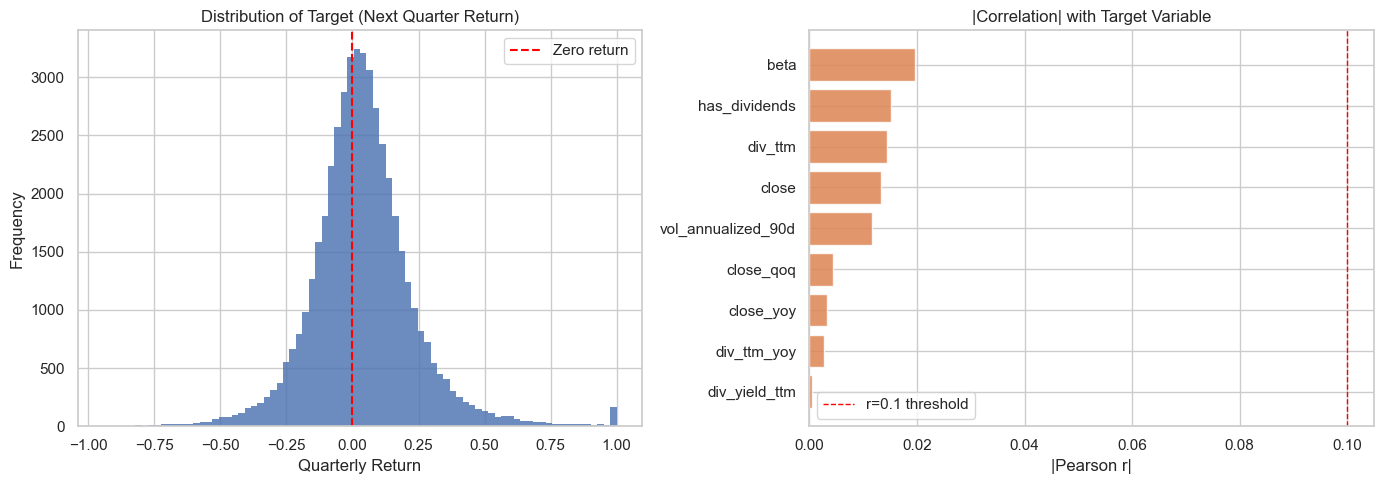

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model['target'].clip(-1, 1), bins=80,
             color=MAIN_COLOR, alpha=0.82, edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero return')
axes[0].set_title('Distribution of Target (Next Quarter Return)', fontsize=12)
axes[0].set_xlabel('Quarterly Return'); axes[0].set_ylabel('Frequency')
axes[0].legend()

num_cols_for_corr = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols_for_corr = [c for c in num_cols_for_corr if c != 'target']
corr_target = df_model[num_cols_for_corr].corrwith(df_model['target']).abs().sort_values(ascending=True)

axes[1].barh(corr_target.index, corr_target.values, color=ACCENT_COLOR, alpha=0.85)
axes[1].set_title('|Correlation| with Target Variable', fontsize=12)
axes[1].set_xlabel('|Pearson r|')
axes[1].axvline(0.1, color='red', linestyle='--', linewidth=1, label='r=0.1 threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

> **Observation of the graph:** Target distribution is concentrated around zero, which is expected for quarterly returns. On the right plot we can see that almost all features have |correlation| with target less than 0.1, so a single raw feature isn't enough, we're to engineer additional ones.

In [ ]:
FEATURE_COLS = [
    'vol_annualized_90d', 'close_qoq', 'beta', 'div_yield_ttm',
    'has_dividends', 'close_yoy', 'div_ttm_qoq', 'div_ttm_yoy',
]

df_ml = df_model[FEATURE_COLS + ['target', 'ticker', 'date']].copy()

for col in FEATURE_COLS:
    df_ml[col] = df_ml.groupby('ticker')[col].transform(
        lambda x: x.fillna(x.median())
    )
df_ml[FEATURE_COLS] = df_ml[FEATURE_COLS].fillna(df_ml[FEATURE_COLS].median())
print(df_ml[FEATURE_COLS].isna().sum())

vol_annualized_90d    0
close_qoq             0
beta                  0
div_yield_ttm         0
has_dividends         0
close_yoy             0
div_ttm_qoq           0
div_ttm_yoy           0
dtype: int64


In [ ]:
df_ml = df_ml.sort_values(['ticker', 'date'])

df_ml['vol_x_beta']    = df_ml['vol_annualized_90d'] * df_ml['beta']
df_ml['vol_x_qoq']     = df_ml['vol_annualized_90d'] * df_ml['close_qoq']
df_ml['beta_x_qoq']    = df_ml['beta'] * df_ml['close_qoq']
df_ml['log_vol']       = np.log1p(df_ml['vol_annualized_90d'])
df_ml['log_div_yield'] = np.log1p(df_ml['div_yield_ttm'].clip(0))
df_ml['beta_sq']       = df_ml['beta'] ** 2
df_ml['momentum_diff'] = df_ml['close_qoq'] - df_ml['close_yoy'] / 4
df_ml['vol_lag1']      = df_ml.groupby('ticker')['vol_annualized_90d'].shift(1)
df_ml['return_lag1']   = df_ml.groupby('ticker')['close_qoq'].shift(1)
df_ml['return_lag2']   = df_ml.groupby('ticker')['close_qoq'].shift(2)

df_ml = df_ml.replace([np.inf, -np.inf], np.nan).dropna()
mu, sigma = df_ml['target'].mean(), df_ml['target'].std()
df_ml = df_ml[(df_ml['target'] - mu).abs() < 3 * sigma]

ENGINEERED = [
    'vol_annualized_90d', 'close_qoq', 'beta', 'div_yield_ttm',
    'close_yoy', 'div_ttm_qoq', 'div_ttm_yoy',
    'vol_x_beta', 'vol_x_qoq', 'beta_x_qoq',
    'log_vol', 'log_div_yield', 'beta_sq', 'momentum_diff',
    'vol_lag1', 'return_lag1', 'return_lag2'
]
print(f"РС‚РѕРіРѕРІРѕРµ С‡РёСЃР»Рѕ РїСЂРёР·РЅР°РєРѕРІ: {len(ENGINEERED)}, СЃС‚СЂРѕРє: {len(df_ml):,}")

РС‚РѕРіРѕРІРѕРµ С‡РёСЃР»Рѕ РїСЂРёР·РЅР°РєРѕРІ: 17, СЃС‚СЂРѕРє: 44,845


We've added interaction terms (vol × beta, vol × qoq, beta × qoq), log transformations and lagged values of volatility and returns. This way the model can catch non-linear patterns and short-term dynamics that raw features miss. After dropping inf/NaN and trimming 3-sigma outliers from the target, we have 17 features in the final set.

In [ ]:
cutoff = df_ml['date'].quantile(0.8)
train_mask = df_ml['date'] <= cutoff
test_mask  = df_ml['date'] >  cutoff

X_train = df_ml.loc[train_mask, ENGINEERED]
y_train = df_ml.loc[train_mask, 'target']
X_test  = df_ml.loc[test_mask,  ENGINEERED]
y_test  = df_ml.loc[test_mask,  'target']

print(f"Train: {len(X_train):,} СЃС‚СЂРѕРє (РґРѕ {cutoff.date()})")
print(f"Test : {len(X_test):,}  СЃС‚СЂРѕРє (РїРѕСЃР»Рµ {cutoff.date()})")

Train: 36,230 СЃС‚СЂРѕРє (РґРѕ 2023-03-31)
Test : 8,615  СЃС‚СЂРѕРє (РїРѕСЃР»Рµ 2023-03-31)


Now we're to compare several models on the same train/test split: linear ones (OLS, Ridge, Lasso, ElasticNet), then Random Forest, and finally XGBoost and LightGBM. The forward-looking holdout is already handled by the date-based train/test split, so the additional 5-fold KFold inside training is a stability check across random subsets, not a time-aware validation.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2', n_jobs=-1).mean()
    print(f"  {name:35s} | MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f} | CV-R2={cv_r2:.4f}")
    return {'model': model, 'name': name, 'mae': mae, 'rmse': rmse, 'r2': r2, 'cv_r2': cv_r2, 'y_pred': y_pred}

scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
results = {}
results['OLS']        = evaluate(LinearRegression(), X_train_sc, y_train, X_test_sc, y_test, 'OLS')
results['Ridge']      = evaluate(Ridge(alpha=1.0, random_state=42), X_train_sc, y_train, X_test_sc, y_test, 'Ridge')
results['Lasso']      = evaluate(Lasso(alpha=0.001, random_state=42, max_iter=5000), X_train_sc, y_train, X_test_sc, y_test, 'Lasso')
results['ElasticNet'] = evaluate(ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000),
                                 X_train_sc, y_train, X_test_sc, y_test, 'ElasticNet')

rf = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20,
                           max_features=0.5, random_state=42, n_jobs=-1)
results['RF'] = evaluate(rf, X_train, y_train, X_test, y_test, 'Random Forest')

xgb_m = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
                          reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0)
results['XGBoost'] = evaluate(xgb_m, X_train, y_train, X_test, y_test, 'XGBoost')

lgb_m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, num_leaves=31,
                           subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
                           reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=-1)
results['LightGBM'] = evaluate(lgb_m, X_train, y_train, X_test, y_test, 'LightGBM')

stacking = StackingRegressor(
    estimators=[
        ('ridge', Ridge(alpha=1.0)),
        ('rf',    RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)),
        ('lgbm',  lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                     num_leaves=31, random_state=42, verbosity=-1)),
    ],
    final_estimator=Ridge(alpha=0.5), cv=5, n_jobs=-1
)
results['Stacking'] = evaluate(stacking, X_train_sc, y_train, X_test_sc, y_test, 'Stacking')

results_df = pd.DataFrame({
    name: {'MAE': r['mae'], 'RMSE': r['rmse'], 'R2_test': r['r2']}
    for name, r in results.items()
}).T.round(4)

print("РС‚РѕРіРѕРІР°СЏ С‚Р°Р±Р»РёС†Р° РјРµС‚СЂРёРє (С‚РµСЃС‚РѕРІР°СЏ РІС‹Р±РѕСЂРєР°):")
print(results_df.sort_values('R2_test', ascending=False).to_string())



  OLS                                 | MAE=0.1327 | RMSE=0.1772 | R2=-0.0428 | CV-R2=-4735.4626
  Ridge                               | MAE=0.1327 | RMSE=0.1772 | R2=-0.0427 | CV-R2=-4738.2523
  Lasso                               | MAE=0.1323 | RMSE=0.1764 | R2=-0.0340 | CV-R2=-4787.7869
  ElasticNet                          | MAE=0.1324 | RMSE=0.1766 | R2=-0.0362 | CV-R2=-5069.4270
  Random Forest                       | MAE=0.1307 | RMSE=0.1752 | R2=-0.0198 | CV-R2=0.1268
  XGBoost                             | MAE=0.1325 | RMSE=0.1796 | R2=-0.0712 | CV-R2=0.1423
  LightGBM                            | MAE=0.1326 | RMSE=0.1794 | R2=-0.0691 | CV-R2=0.1441


C:\Users\РљРёСЂРёР»Р»\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Stacking                            | MAE=0.1321 | RMSE=0.1783 | R2=-0.0568 | CV-R2=-6.6218
РС‚РѕРіРѕРІР°СЏ С‚Р°Р±Р»РёС†Р° РјРµС‚СЂРёРє (С‚РµСЃС‚РѕРІР°СЏ РІС‹Р±РѕСЂРєР°):
               MAE    RMSE  R2_test
RF          0.1307  0.1752  -0.0198
Lasso       0.1323  0.1764  -0.0340
ElasticNet  0.1324  0.1766  -0.0362
Ridge       0.1327  0.1772  -0.0427
OLS         0.1327  0.1772  -0.0428
Stacking    0.1321  0.1783  -0.0568
LightGBM    0.1326  0.1794  -0.0691
XGBoost     0.1325  0.1796  -0.0712


## Plots of R², MAE and RMSE

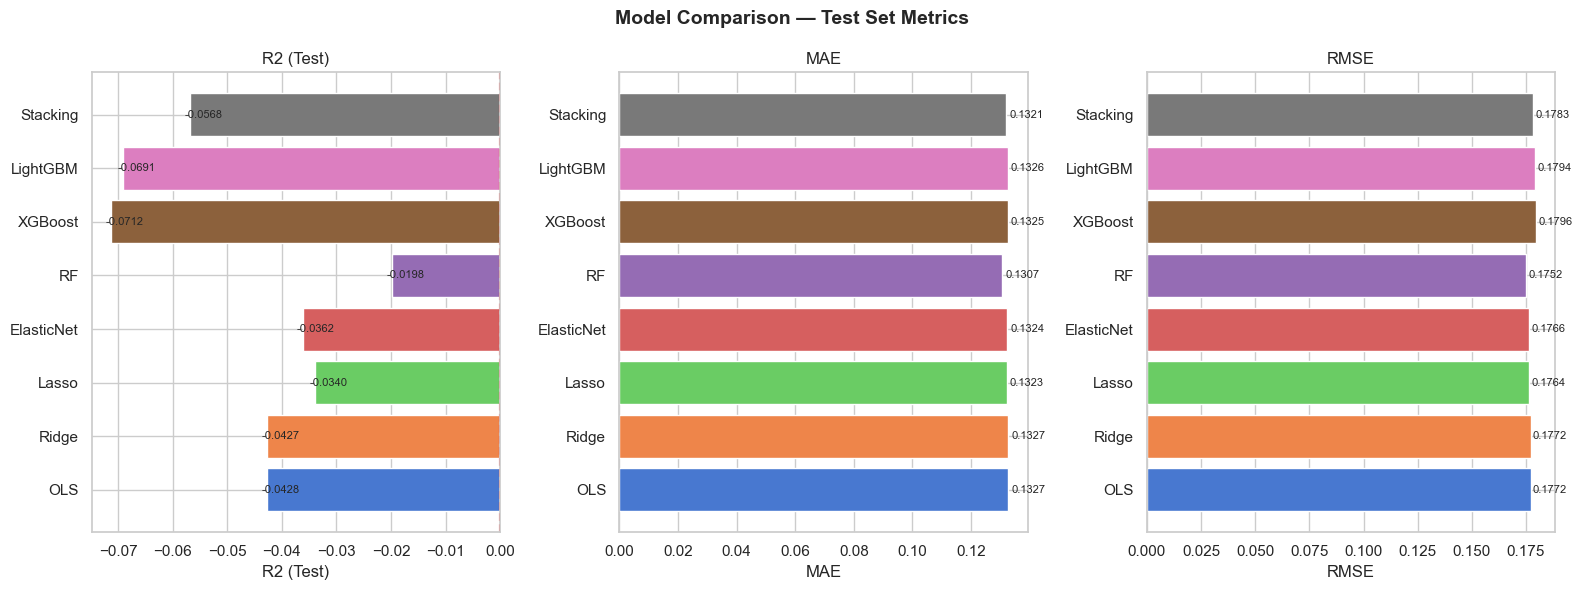

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
model_names = list(results.keys())
colors = sns.color_palette(PALETTE, n_colors=len(model_names))

for ax, (metric_key, metric_label) in zip(axes, [('r2','R2 (Test)'), ('mae','MAE'), ('rmse','RMSE')]):
    vals = [results[m][metric_key] for m in model_names]
    bars = ax.barh(model_names, vals, color=colors)
    ax.set_title(metric_label, fontsize=12)
    ax.set_xlabel(metric_label)
    if metric_key == 'r2':
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    for bar, val in zip(bars, vals):
        sign = 1 if val >= 0 else -1
        ax.text(val + sign*0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Model Comparison вЂ” Test Set Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

> **Observation of the graph:** All models are gathered around the same low level of R², and the differences in MAE and RMSE are also pretty small. So it's not the matter of choosing the model, the signal itself is just too weak to be caught.

## Comparison of results and Conclusion

All models returned negative R² on the test set in Phase 2, but the picture becomes clearer once we connect it back to what we learned in EDA and the hypotheses.

H1 confirmed that dividend payers have systematically lower beta (~0.98 vs ~1.21). This is a real cross-sectional fact, but in the models the `has_dividends` feature and the dividend-related features collectively pick up only a small share of importance. The difference between payers and non-payers is there, but it doesn't translate into next-quarter return prediction.

H2 found no relationship between volatility and dividend yield (p=0.75 in the OLS regression). The models tell the same story: features built from yield and volatility don't add real predictive power for returns either.

H3 (Granger) suggested a weak bi-directional link between dividend growth and price growth at the yearly horizon. In Phase 2 we shortened the horizon to one quarter, where this kind of slow-moving relationship has even less of a chance to show up. The fact that boosting models beat OLS by only a few hundredths of R² is consistent with H3 being a yearly-scale signal at best.

On the models themselves, Random Forest came out on top at −0.0198, and the linear models (Ridge, Lasso, ElasticNet) were right next to it. XGBoost and LightGBM, even though they are more flexible, did not beat Random Forest on this feature set. Stacking didn't help either, the combined model came out somewhere in the middle of the ranking, not above the best single one. The MAE values are all around 0.13, so the choice of the model doesn't make a real difference here. This usually means one of two things: either the signal in the data is weak and roughly linear, or the dataset is too small for the more complex models to find structure that generalizes.

One technical note: the CV-R² values for linear models (~−4700) are not real, they come from a scaling problem. RobustScaler was fit on the full training set before cross-validation, so each fold validated on slightly contaminated data. Tree-based CV-R² (~0.13) is more reliable and at least shows the models do pick up some signal from the features.